<a href="https://colab.research.google.com/github/Redd-hope/HumanPatterns/blob/main/FaceEmotionDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sat Nov  8 21:17:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P0             16W /   95W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics 

In [3]:
import torch
print(" PyTorch version:", torch.__version__)
print(" CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(" GPU name:", torch.cuda.get_device_name(0))

 PyTorch version: 2.6.0+cu124
 CUDA available: True
 GPU name: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.225  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Setup complete  (16 CPUs, 15.7 GB RAM, 328.7/929.6 GB disk)


In [5]:
from ultralytics import YOLO
from IPython.display import Image

In [6]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="aOb4gFjOGGycb6ErUJTF")
project = rf.workspace("skripsi2-1r20w").project("data-primer-2")
version = project.version(9)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


In [7]:
dataset.location

'c:\\Users\\anike\\OneDrive\\Desktop\\ds project\\HumanPatterns\\data-primer-2-9'

In [8]:
!yolo task=detect mode=train model=yolov8n.pt data="C:\Users\anike\OneDrive\Desktop\ds project\HumanPatterns\data-primer-2-9\data.yaml" epochs=50 imgsz=640

New https://pypi.org/project/ultralytics/8.3.226 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.225  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\anike\OneDrive\Desktop\ds project\HumanPatterns\data-primer-2-9\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum

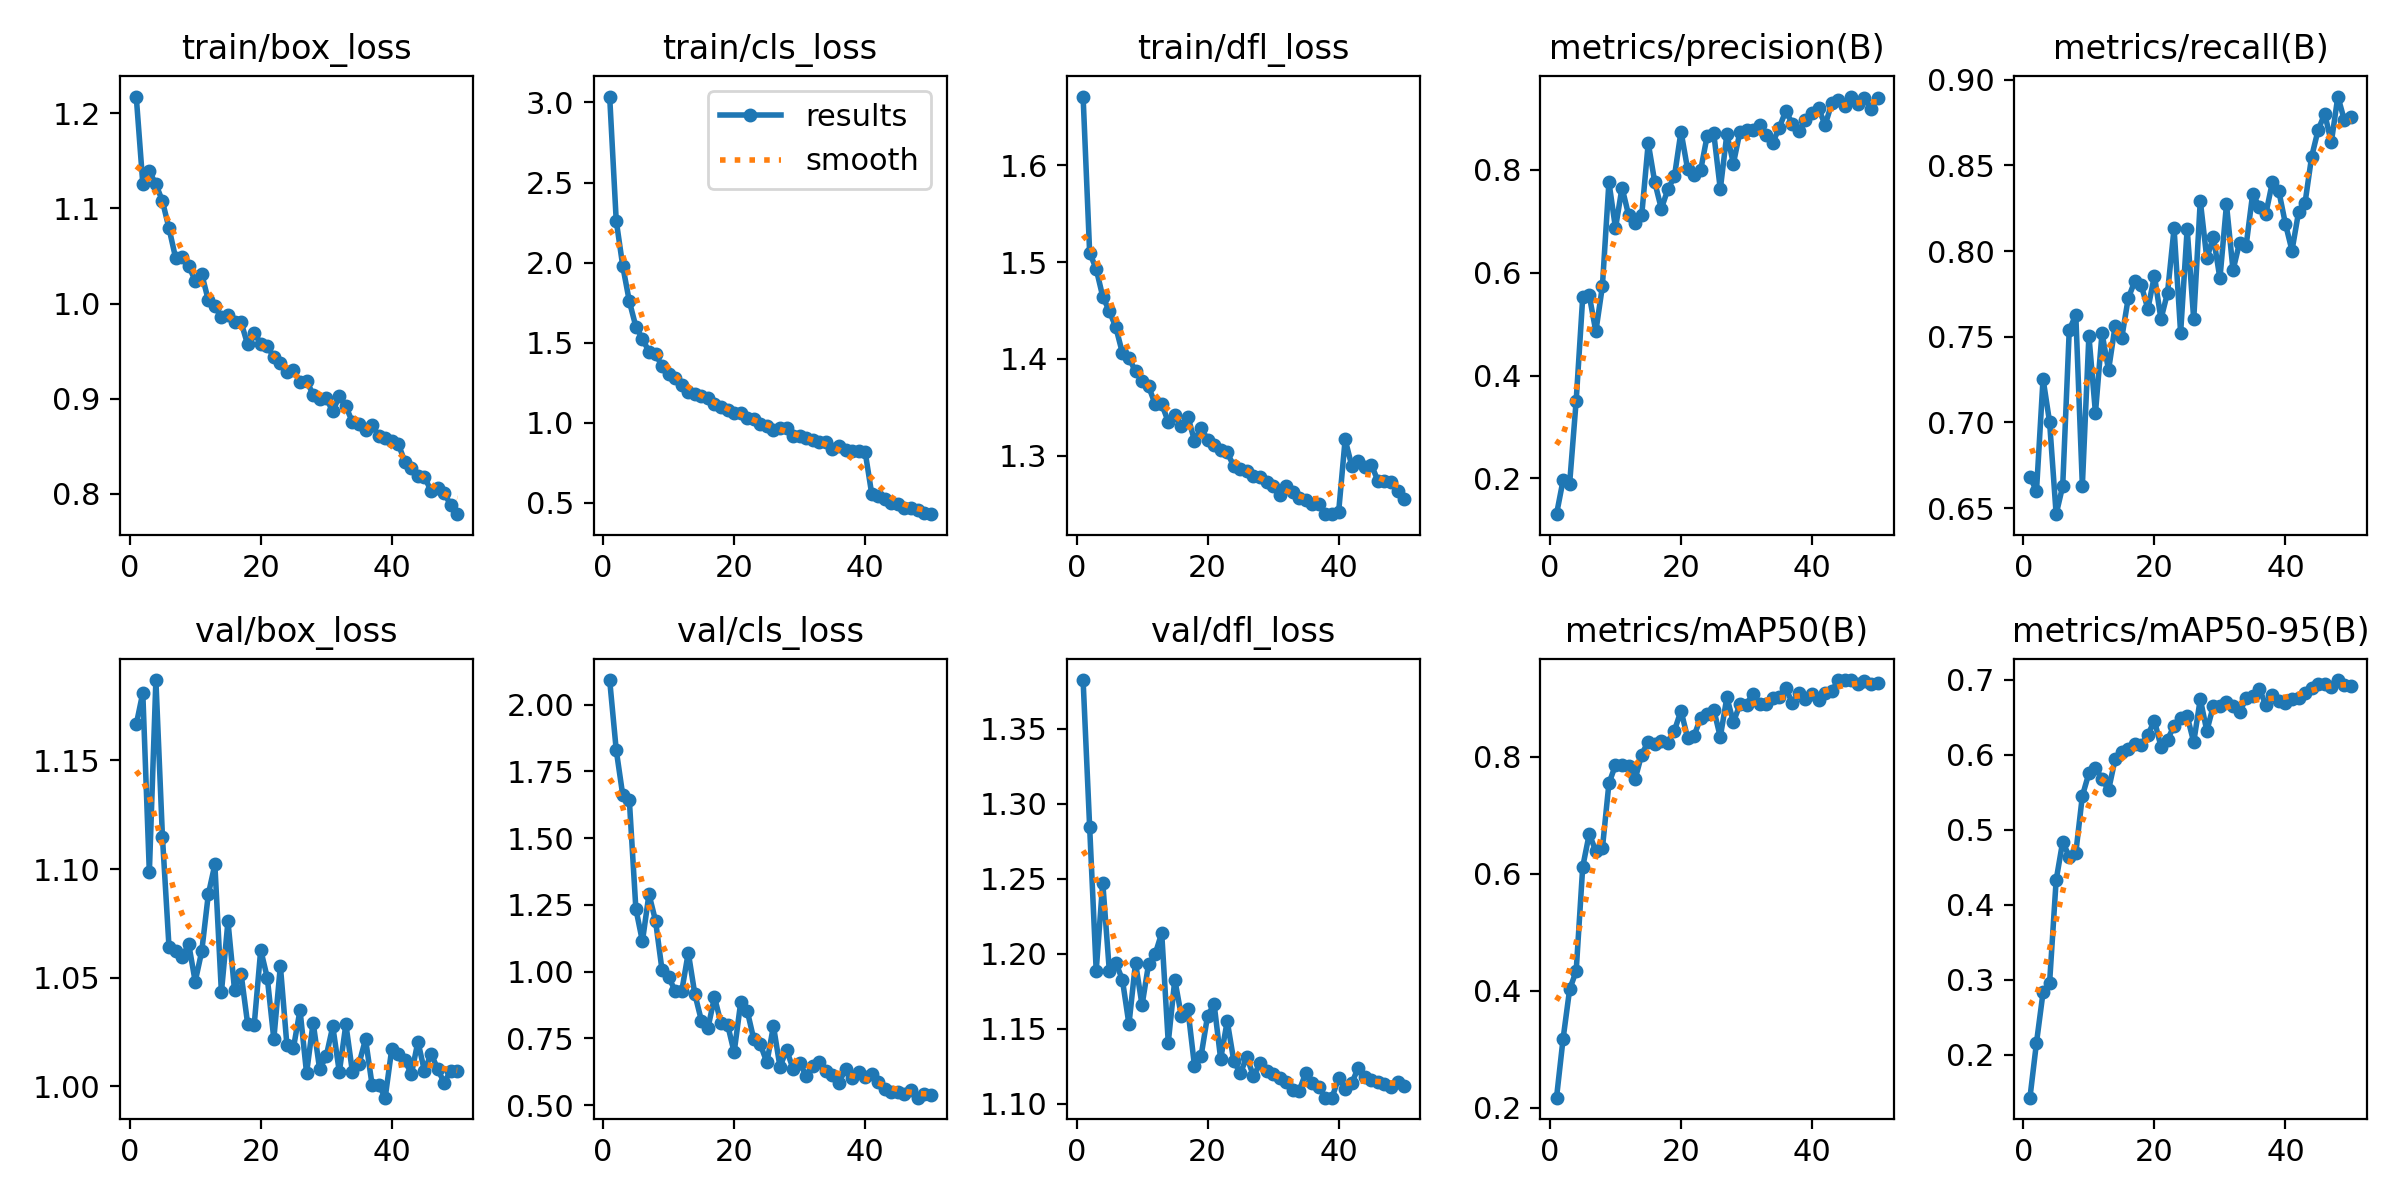

In [14]:
from IPython.display import Image
Image(filename='runs/detect/train2/results.png', width=600)
# # Check the contents of the runs directory
# !ls /content/runs/detect/train2/

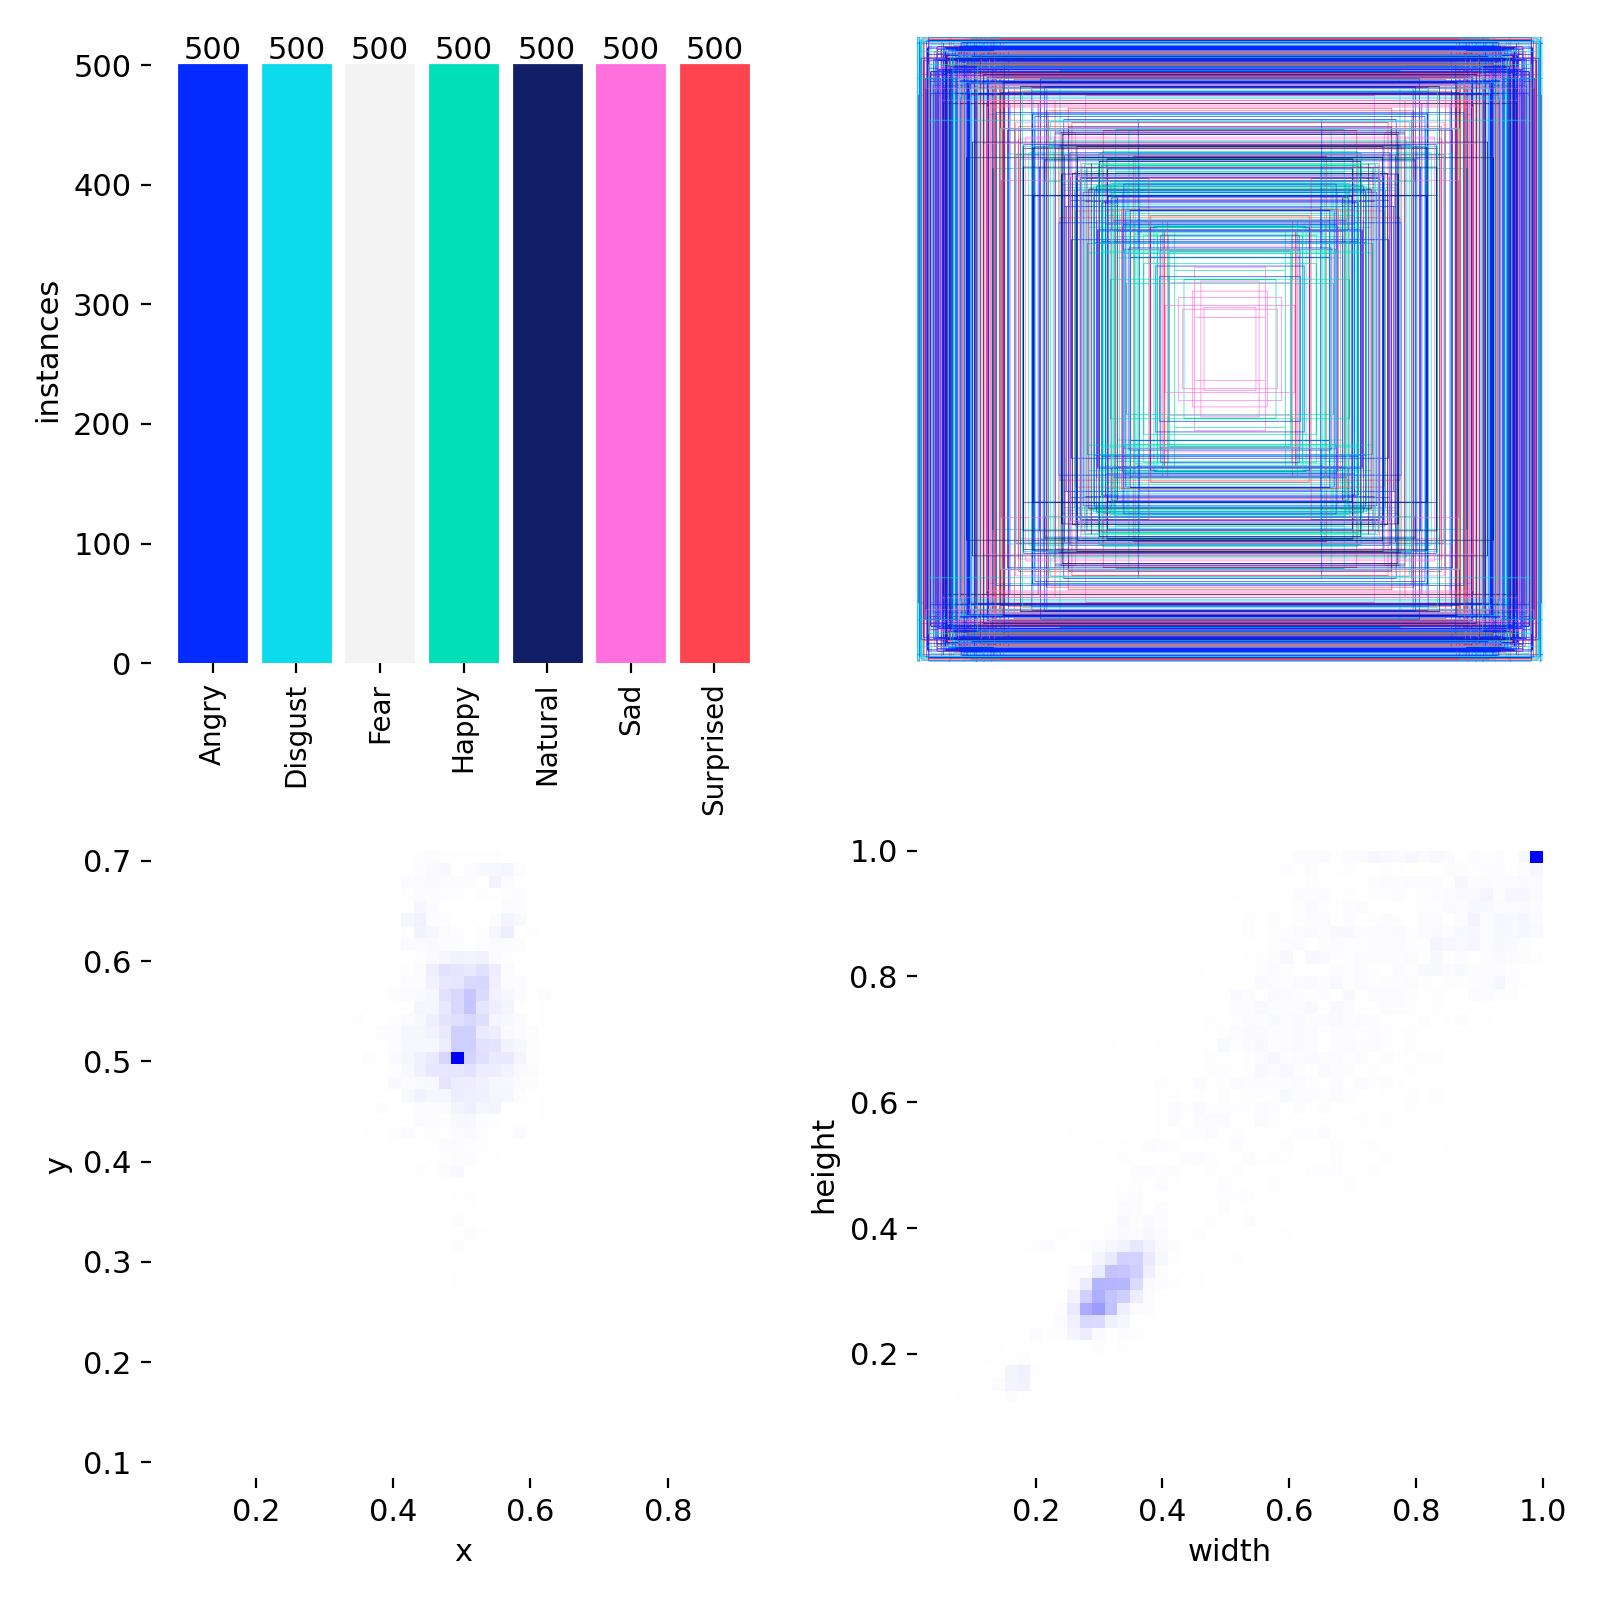

In [15]:
Image('runs/detect/train2/labels.jpg', width=600)

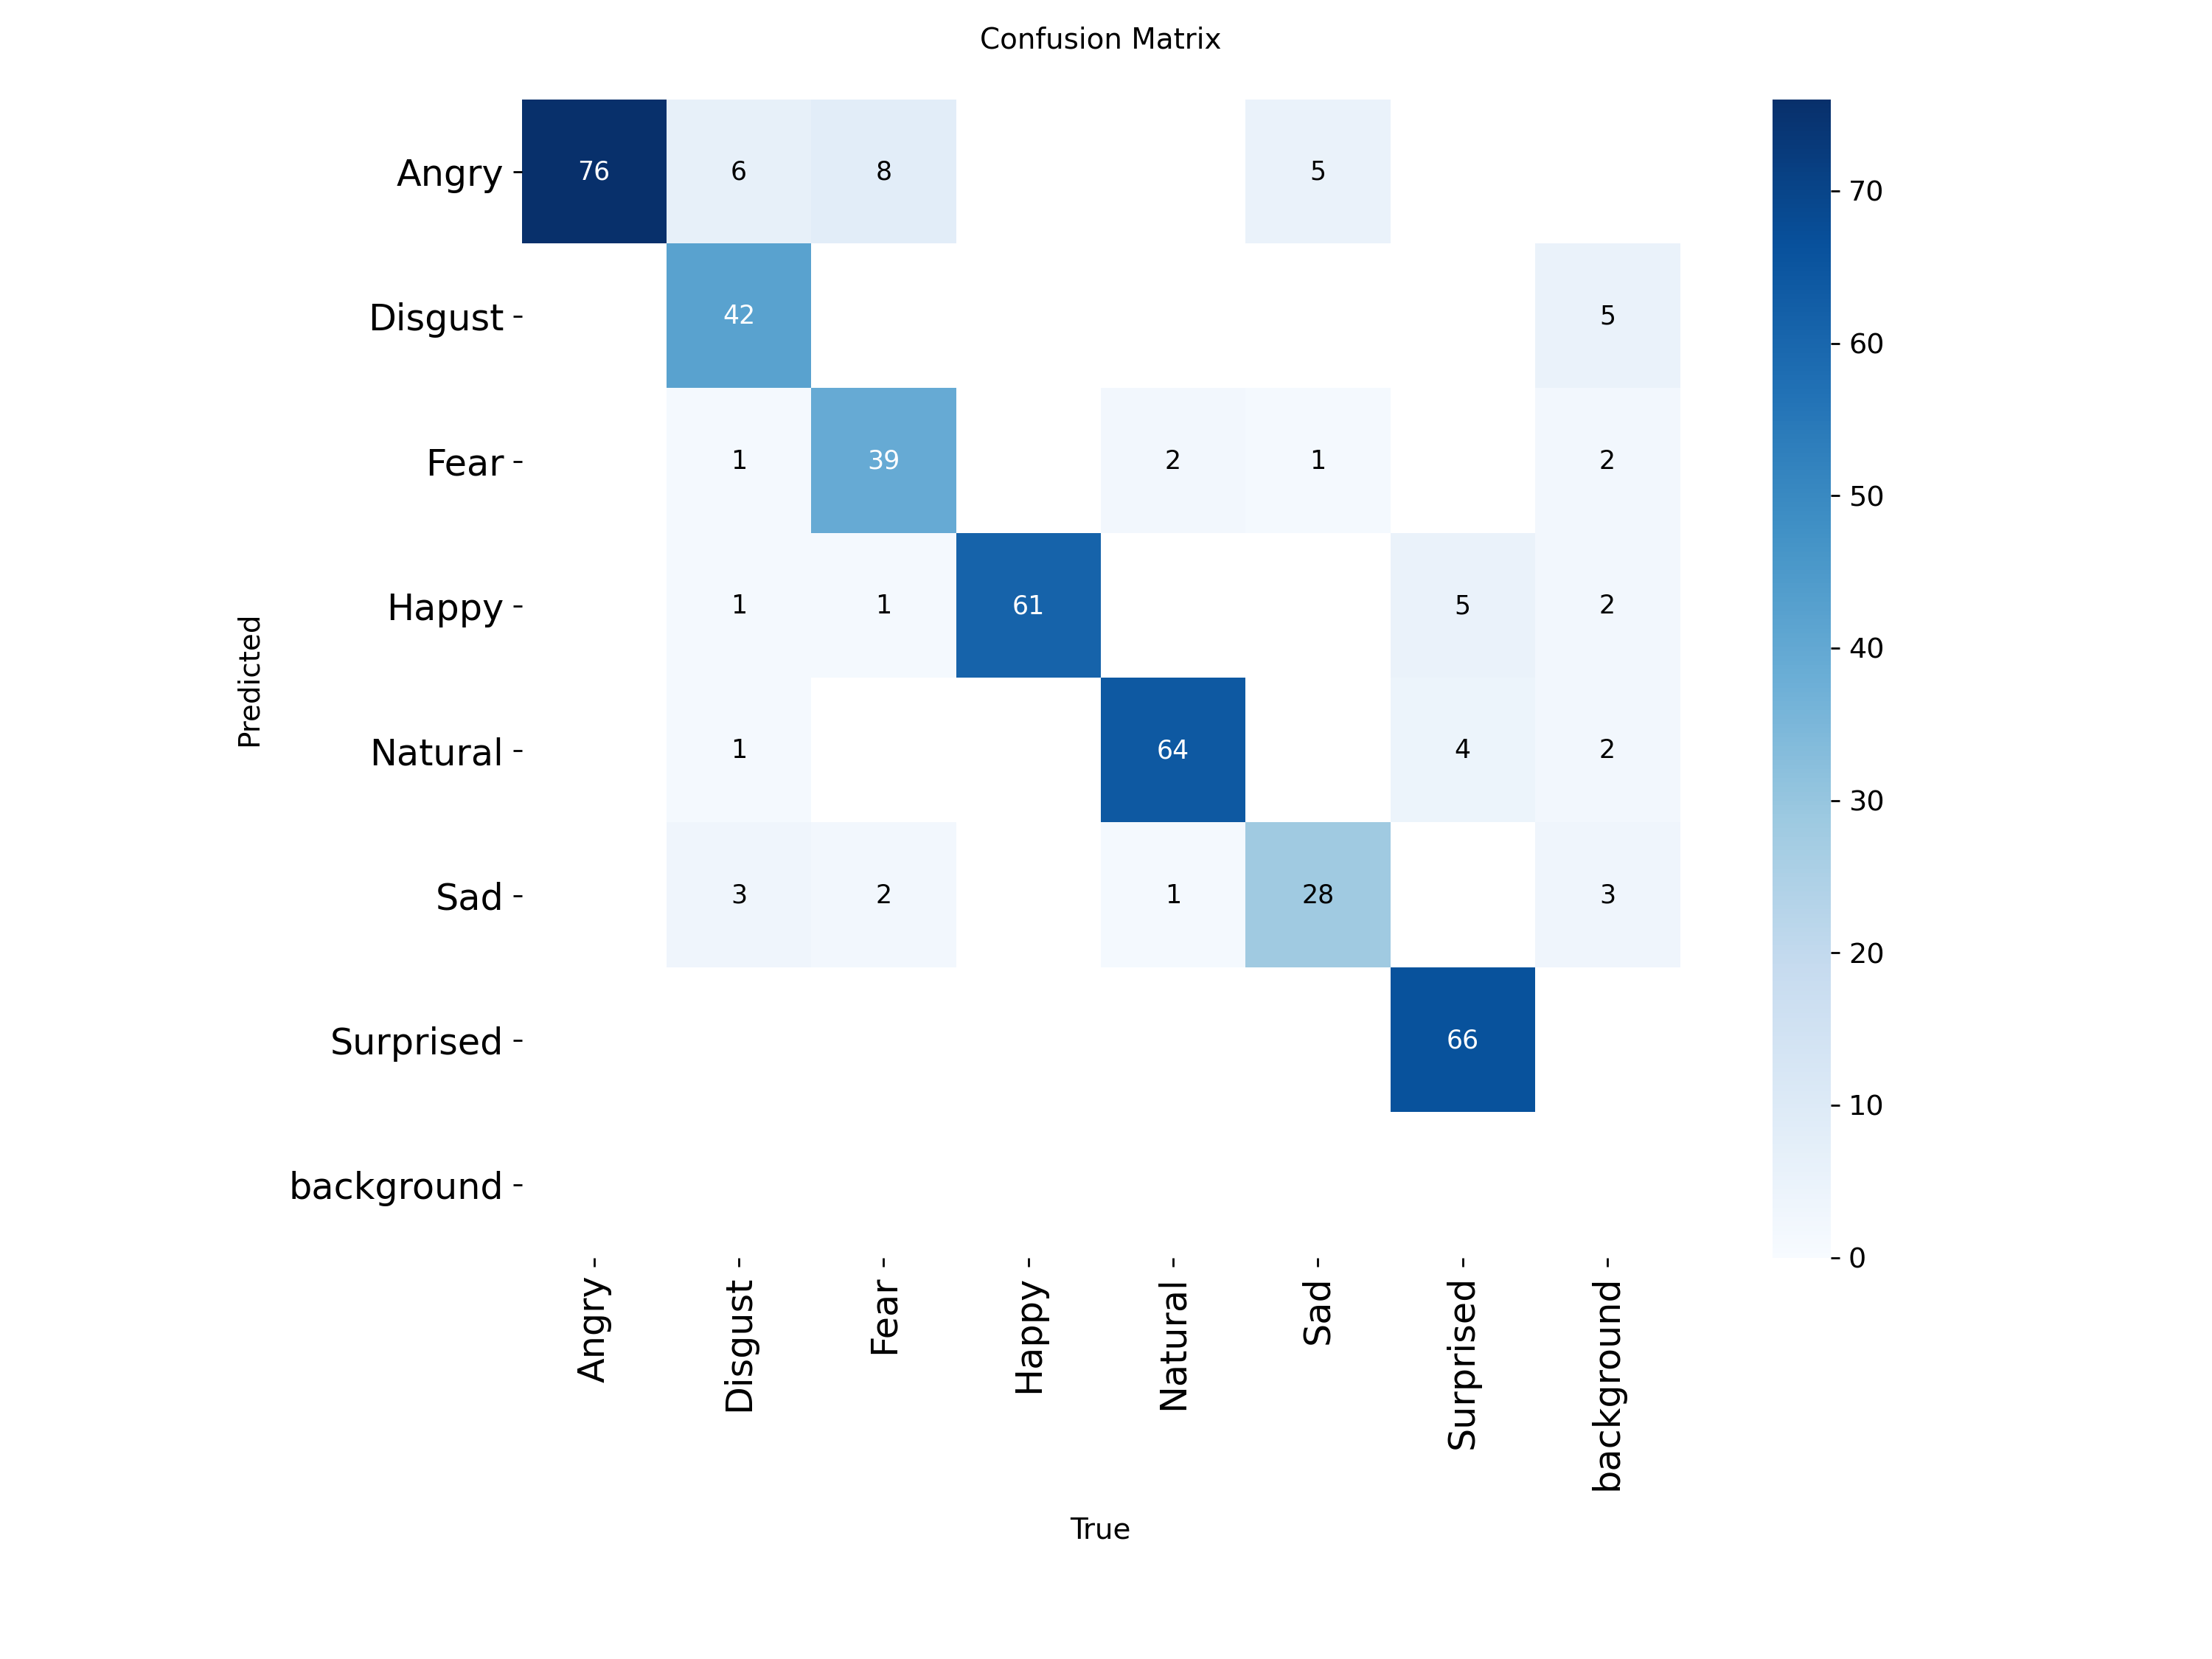

In [16]:
Image('runs/detect/train2/confusion_matrix.png', width=600)

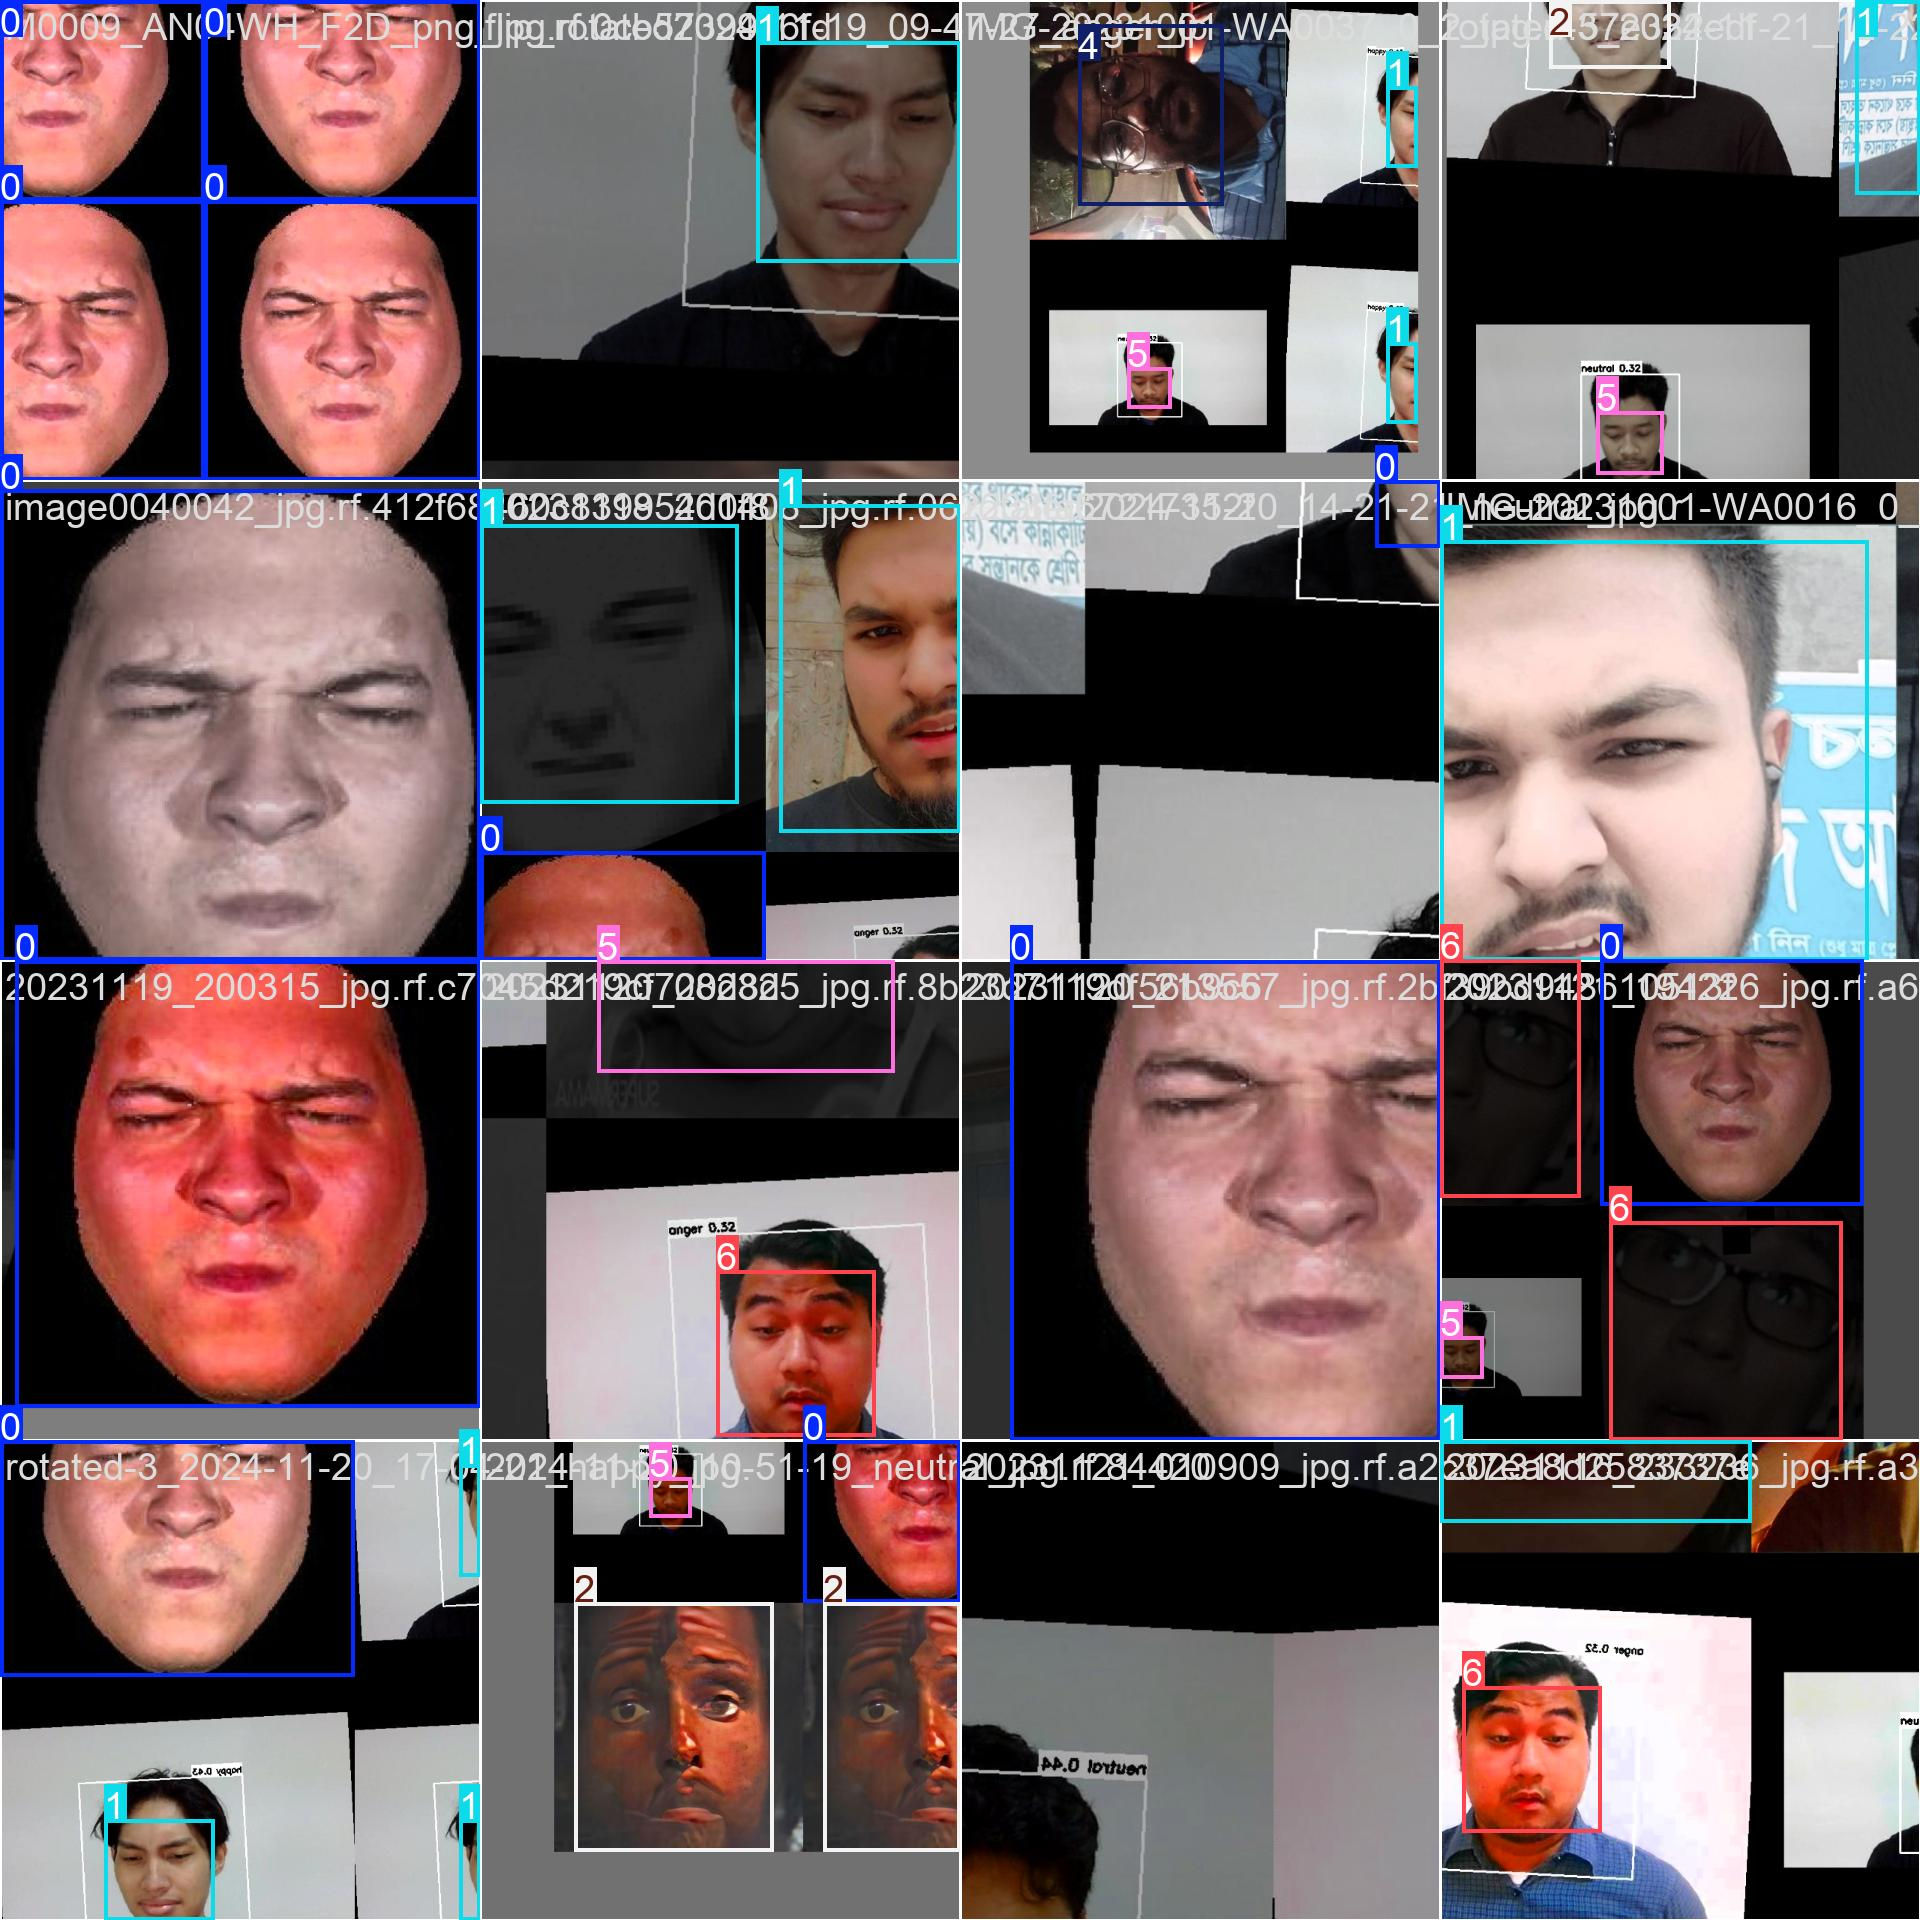

In [17]:
Image('runs/detect/train2/train_batch0.jpg', width=600)

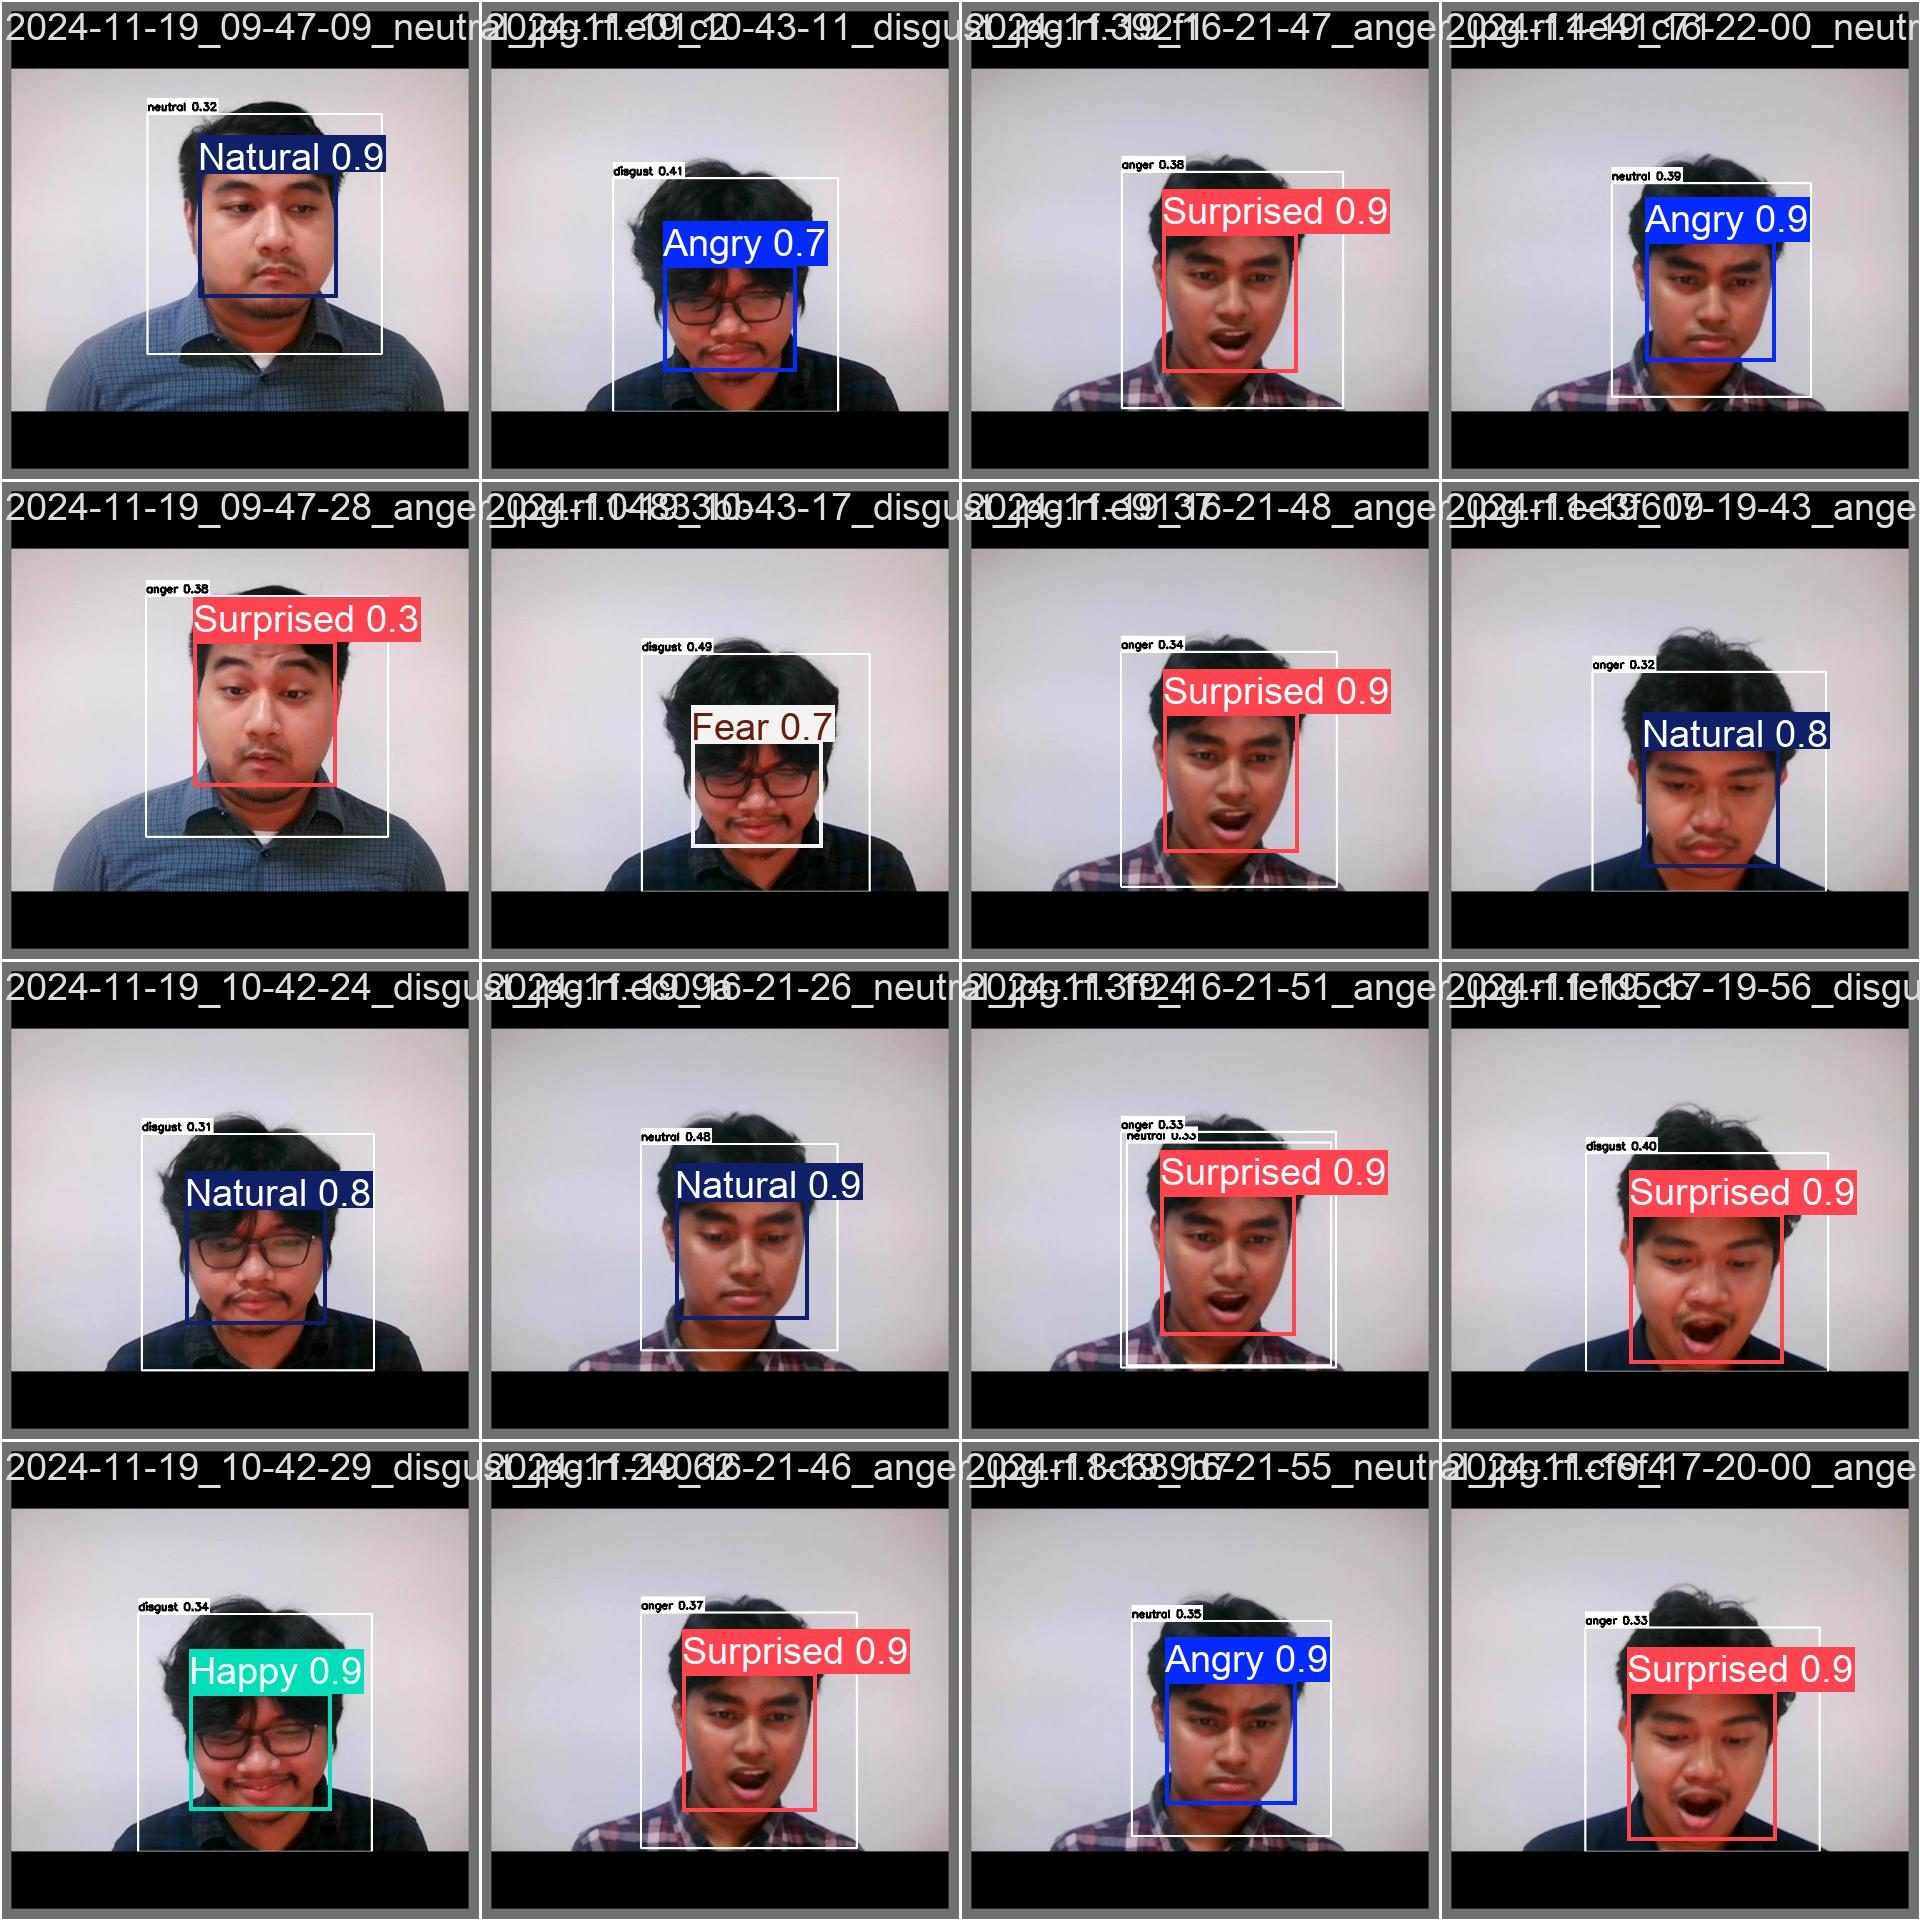

In [18]:
Image('runs/detect/train2/val_batch0_pred.jpg', width=600)

In [20]:
!yolo task=detect mode=val model="runs/detect/train2/weights/best.pt" data="C:/Users/anike/OneDrive/Desktop/ds project/HumanPatterns/data-primer-2-9/data.yaml"


Ultralytics 8.3.225  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 424.782.3 MB/s, size: 24.4 KB)

val: Scanning C:\Users\anike\OneDrive\Desktop\ds project\HumanPatterns\data-primer-2-9\valid\labels.cache... 417 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 417/417  0.0s
val: Scanning C:\Users\anike\OneDrive\Desktop\ds project\HumanPatterns\data-primer-2-9\valid\labels.cache... 417 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 417/417  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 4% ──────────── 1/27 0.6it/s 0.5s<41.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 7% ╸─────────── 2/27 2.2it/s 0.6s<11.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 11% ━─────────── 3/27

In [24]:
!yolo task=detect mode=predict model="C:/Users/anike/OneDrive/Desktop/ds project/HumanPatterns/runs/detect/train2/weights/best.pt" source="C:/Users/anike/OneDrive/Desktop/ds project/HumanPatterns/data-primer-2-9/test/images" conf=0.25 save=True


Ultralytics 8.3.225  Python-3.11.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs

image 1/162 C:\Users\anike\OneDrive\Desktop\ds project\HumanPatterns\data-primer-2-9\test\images\2024-11-19_09-47-10_anger_jpg.rf.0bd41493c95893276dd8777f44f18947.jpg: 640x640 1 Natural, 4.9ms
image 2/162 C:\Users\anike\OneDrive\Desktop\ds project\HumanPatterns\data-primer-2-9\test\images\2024-11-19_09-47-50_disgust_jpg.rf.1e6010df0bb48a74e605c658e5773cce.jpg: 640x640 1 Disgust, 4.9ms
image 3/162 C:\Users\anike\OneDrive\Desktop\ds project\HumanPatterns\data-primer-2-9\test\images\2024-11-19_10-42-25_disgust_jpg.rf.6b785c181364488d22a4dc4a6753da63.jpg: 640x640 1 Natural, 7.0ms
image 4/162 C:\Users\anike\OneDrive\Desktop\ds project\HumanPatterns\data-primer-2-9\test\images\2024-11-19_10-42-35_disgust_jpg.rf.b6529406b4c656ea5782d8e818f8c494.jpg: 640x640 1 Surprised, 6.9ms
image 5/162 C:\Users\anike\On

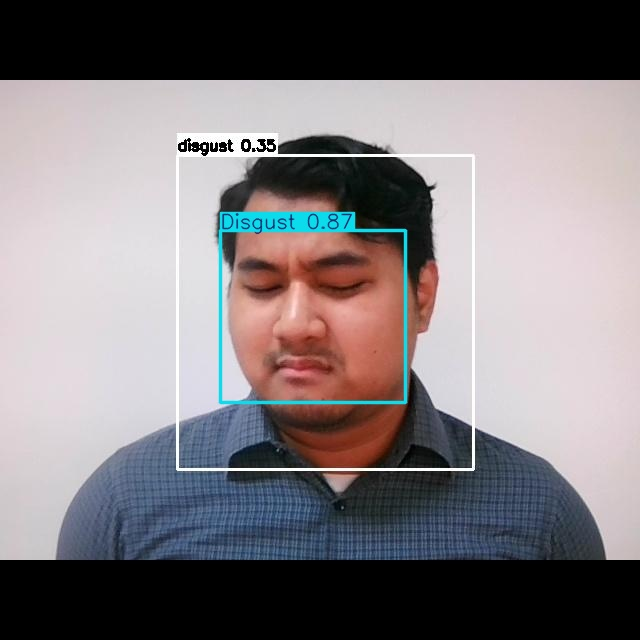

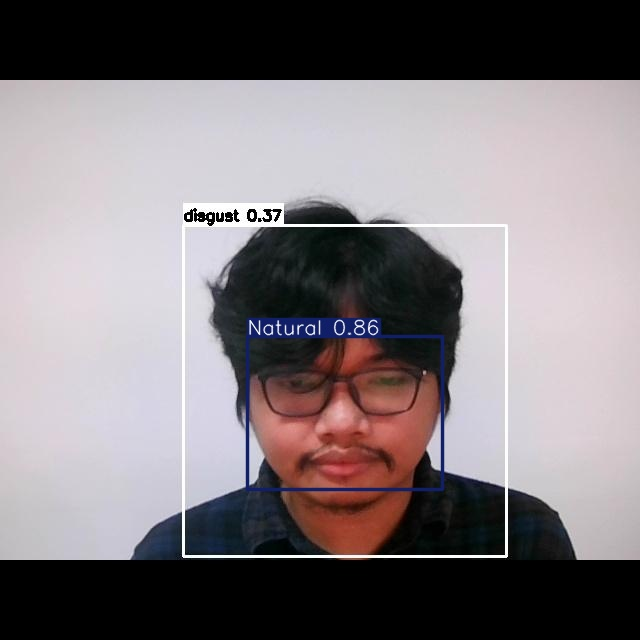

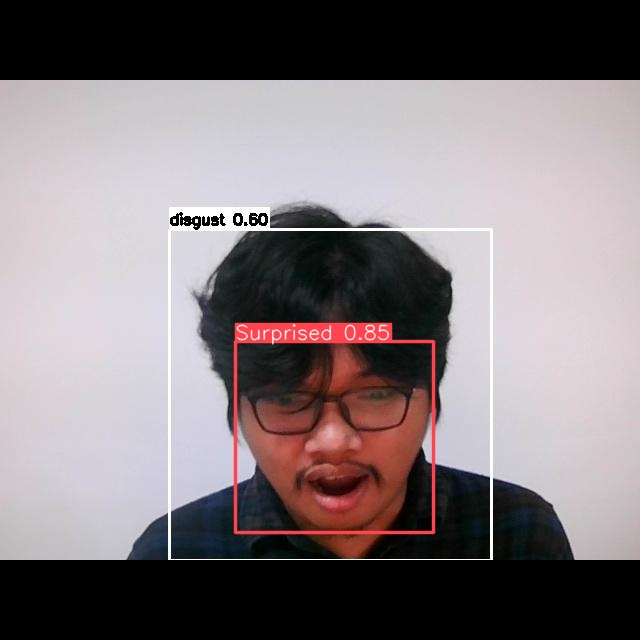

In [26]:
import glob
import os
from IPython.display import Image as IPyImage, display

# Adjust path to your Windows environment (use forward slashes)
base_path = "C:/Users/anike/OneDrive/Desktop/ds project/HumanPatterns/runs/detect"
latest_folder = max(glob.glob(f'{base_path}/predict*/'), key=os.path.getmtime)

# Show a few sample predictions
for image_path in glob.glob(f'{latest_folder}/*.jpg')[1:4]:
    display(IPyImage(filename=image_path, width=600))
    print("\n")


In [27]:
from google.colab import files
files.download("runs/detect/train2/weights/best.pt")


ModuleNotFoundError: No module named 'google'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [29]:
import shutil

src = "C:/Users/anike/OneDrive/Desktop/ds project/HumanPatterns/runs/detect/train2"
dst = "C:/Users/anike/OneDrive/Desktop/yolo_results/train2"

shutil.copytree(src, dst, dirs_exist_ok=True)
print("Copied YOLO results to:", dst)


Copied YOLO results to: C:/Users/anike/OneDrive/Desktop/yolo_results/train2


In [33]:
import os
import ultralytics

# Step 1: Check Ultralytics install path
print("📁 Ultralytics installed at:", ultralytics.__file__)

# Step 2: Try to locate YOLOv8n config inside Ultralytics
ultralytics_path = os.path.dirname(ultralytics.__file__)
yaml_path = os.path.join(ultralytics_path, "cfg", "models", "v8", "yolov8n.yaml")

if os.path.exists(yaml_path):
    print("✅ Found yolov8n.yaml inside ultralytics package.")
else:
    print("⚠️ File not found inside ultralytics package. Creating it manually...")

    model_yaml = """
# YOLOv8n model configuration
# Parameters
nc: 80  # number of classes (change this for your dataset)
depth_multiple: 0.33
width_multiple: 0.25

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, C2f, [128]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 6, C2f, [256]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 6, C2f, [512]]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 3, C2f, [1024]]
  - [-1, 1, SPPF, [1024, 5]]

head:
  - [-1, 1, Conv, [512, 1, 1]]
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]
  - [-1, 1, Conv, [256, 1, 1]]
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]
  - [[17, 20, 23], 1, Detect, [nc]]
"""

    # Save the model config locally
    with open("yolov8n.yaml", "w") as f:
        f.write(model_yaml)
    print("✅ Created yolov8n.yaml manually in current directory.")

# Step 3: Copy or move to teacher model folder
os.makedirs("yolo_teacher_model", exist_ok=True)
os.system("cp yolov8n.yaml yolo_teacher_model/model.config")

print("📦 Copied model config to yolo_teacher_model/model.config")


📁 Ultralytics installed at: c:\Users\anike\OneDrive\Desktop\ds project\HumanPatterns\venv\Lib\site-packages\ultralytics\__init__.py
⚠️ File not found inside ultralytics package. Creating it manually...
✅ Created yolov8n.yaml manually in current directory.
📦 Copied model config to yolo_teacher_model/model.config


In [34]:
import shutil
import os

# Make sure the destination folder exists
os.makedirs("yolo_teacher_model", exist_ok=True)

shutil.copy("yolov8n.yaml", "yolo_teacher_model/model.config")
print("✅ Copied to yolo_teacher_model/model.config")


✅ Copied to yolo_teacher_model/model.config


In [36]:
from ultralytics import YOLO

model = YOLO("runs/detect/train2/weights/best.pt")
model.info()

Model summary: 129 layers, 3,012,213 parameters, 0 gradients, 8.2 GFLOPs


(129, 3012213, 0, 8.2006016)

In [38]:
# Save entire model (easy to load later)
torch.save(model, "emotion_model.pt")

# OR save just weights (recommended for deployment)
torch.save(model.state_dict(), "emotion_model_weights.pt")

print("💾 Emotion model saved successfully!")


💾 Emotion model saved successfully!
